##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** Rabbitions

**Student names & numbers:**
* [Sanne Jimkes] - [000101379]
* [Naimi de Jong] - [000100775]


---

## 0. Iteration setup

**Import libraries**

In [11]:
# CODE CELL: import the necessary libraries for this iteration

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Load and merge datasets**

In [3]:
# CODE CELL: import the necessary datasets for this iteration
# Make sure to load your cleaned dataset from Iteration 1 AND the new inspection data for Iteration 2.
# Merge them together based on the Ship_ID.

df_inv = pd.read_csv("../data/clean_it1_inventory.csv")
df_inspec = pd.read_csv("../data/ship_inspections_iter2.csv")
# Merge the inventory and inspection datasets on Ship_ID
df = pd.merge(df_inv, df_inspec, on="Ship_ID", how="left")

---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

*Describe the problem surrounding the safety inspections. Why is the current process (human estimation/gut feeling) a risk?*

* The inspection data is stored in a separate dataset from the inventory data. Some columns also contain missing values and unusual reactor power values. Ship condition is currently judged mostly by mechanic notes and human judgement. This “gut feeling” approach can lead to inconsistent evaluations. Ships with serious technical problems might still be labeled as safe, which creates safety risks and possible financial losses.

**Business objective(s)**

*Justify why a standardized, rule-based expert system is needed.*

* A standardized rule-based system is needed to evaluate ships in a consistent way. The system will classify ships into three categories: Pristine, Operational, or Critical. This helps the sales team quickly understand the ship’s condition and reduces the risk of selling unsafe ships. It also ensures every ship is evaluated using the same rules.

**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

* The data mining task in this iteration is a classification problem because ships are placed into categories (Pristine, Operational, Critical). The classification will use variables such as Model_Cycle, Galactic_Credits, Propulsion_Type, and Reactor_Power to determine the condition of each ship.

**Success criteria**

*Determine success criteria for this iteration*

* Success in this iteration means the inventory and inspection datasets are merged correctly, missing values are handled, and suspicious reactor outliers are identified. The rule-based model should also produce a realistic mix of ship categories and perform reasonably well when compared with the Hull_Integrity notes using metrics such as accuracy and a confusion matrix.

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*

In [8]:
# CODE CELL: Show basic statistics and information
# Summary statistics
df.describe(include='all')

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class
count,3.683140e+05,368314.000000,360916.000000,368314,368314,368314,338876.000000,311704,368314
unique,NaN,NaN,NaN,28,51,3,NaN,8,8
top,NaN,NaN,NaN,Independent Shipwrights,Calodan Expanse,Operational,NaN,Ion Drive,Shuttle
freq,NaN,NaN,NaN,94322,42091,141273,NaN,177373,125707
mean,7.311484e+09,19454.237615,7511.263984,NaN,NaN,NaN,71.592559,NaN,NaN
std,4.381194e+06,15542.661057,9.079721,NaN,NaN,NaN,44.644147,NaN,NaN
min,7.301583e+09,501.000000,7400.000000,NaN,NaN,NaN,30.000000,NaN,NaN
25%,7.308103e+09,7950.000000,7508.000000,NaN,NaN,NaN,40.000000,NaN,NaN
50%,7.312604e+09,15990.000000,7513.000000,NaN,NaN,NaN,60.000000,NaN,NaN
75%,7.315244e+09,27990.000000,7517.000000,NaN,NaN,NaN,80.000000,NaN,NaN


The dataset contains numerical and categorical variables. Numerical variables include Ship_ID, Galactic_Credits, Model_Cycle, and Reactor_Power because they contain numbers. Categorical variables include Ship_Manufacturer, Sector, Hull_Integrity, Propulsion_Type, and Ship_Class because they describe categories.

From the summary statistics table, Reactor_Power ranges from 30 to 360. The average reactor power is about 71.6, which means most ships have reactor power around this value, but some ships have much higher power.

The table also shows a clear outlier in Galactic_Credits, where the maximum value is 777,777, which is much higher than the typical values in the dataset.

**Visualizations and patterns**

*Discover patterns in the data that will help you determine the inspection rules. Create visualizations that show the relationship between variables like Reactor_Power, Propulsion_Type, Ship_Class on one side, and the target variable Hull_Integrity on the other. Describe any hard rules you discover (e.g., relationships with dangerous reactors or advanced tech).*

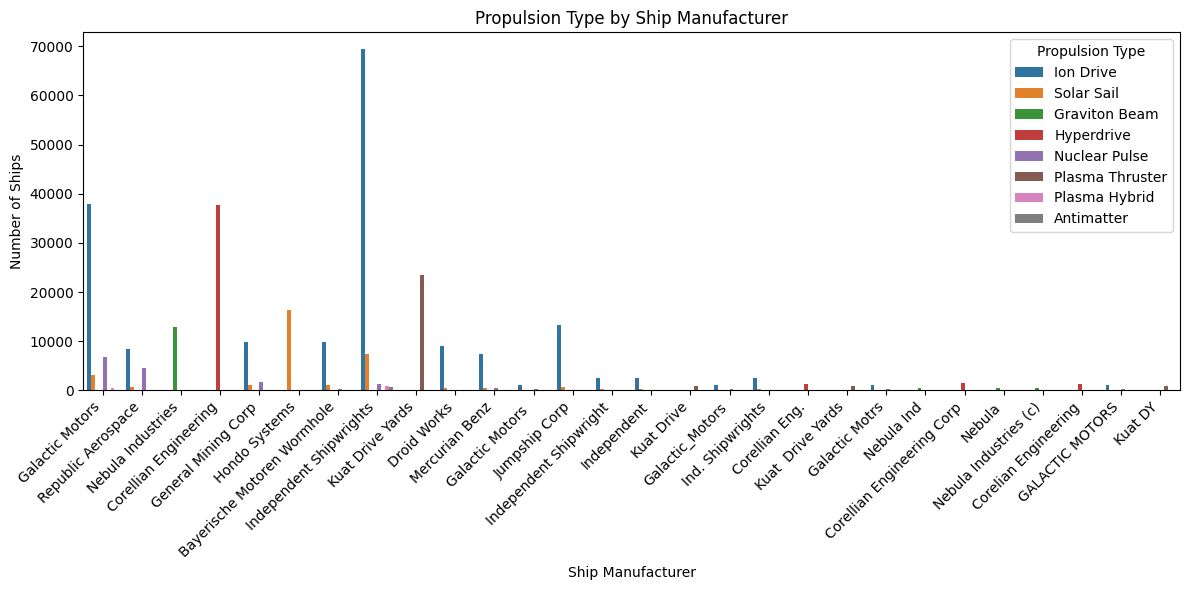

In [21]:
# Countplot to show manufacturer vs propulsion type
plt.figure(figsize=(12,6))
sns.countplot(x='Ship_Manufacturer', hue='Propulsion_Type', data=df)
plt.title('Propulsion Type by Ship Manufacturer')
plt.xlabel('Ship Manufacturer')
plt.ylabel('Number of Ships')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Propulsion Type')
plt.tight_layout()
plt.show()

Manufacturers in here are extremely specialized. If you have a missing Propulsion Type, look at the Ship Manufacturer first:

Nebula Industries = Graviton Beam.

Corellian Engineering = Hyperdrive.

General Mining Corp = Ion Drive.

Hondo Systems = Solar Sail.

Bayerische Motoren Wormhole = Ion Drive.

Kuat Drive Yards = Plasma Thruster.

Droid Works = Plasma Thruster.

Kuat Drive = Plasma Thruster.

Nebula Ind = Graviton Beam.

Corellian Engineering Corp = Hyperdrive.

Nebula = Graviton Beam.

Nebula Industries (c) = Graviton Beam.

Corelian Engineering = Hyperdrive.

Kuat DY = Plasma Thruster.

And the rest are Ion Drive since that is the most common Propulsion Type (the above are basically just exeptions)



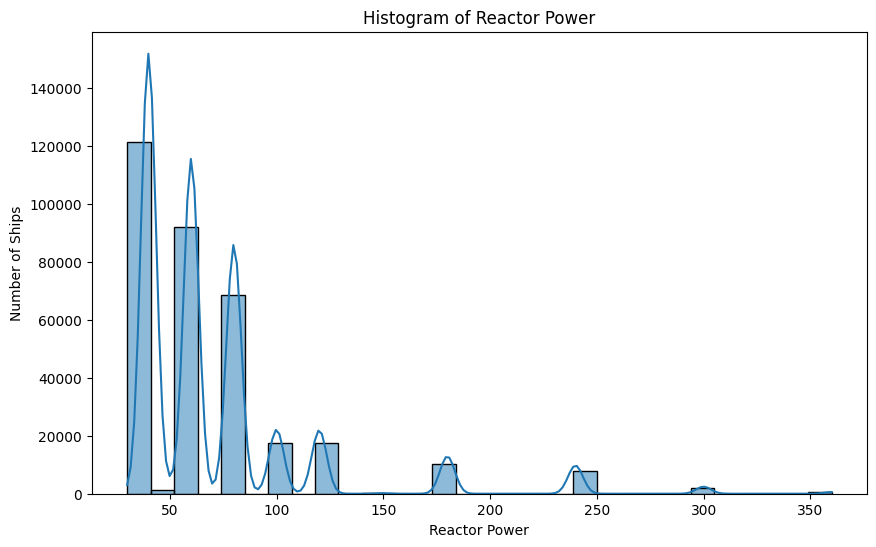

In [29]:
plt.figure(figsize=(10,6))
sns.histplot(df['Reactor_Power'], bins=30, kde=True)
plt.title('Histogram of Reactor Power')
plt.xlabel('Reactor Power')
plt.ylabel('Number of Ships')
plt.show()

You cannot use a global average to fill missing reactor powers because your fleet has different engineering tiers.

Problem with averages: the data has multiple peaks. A global average would fall between them, creating values that don’t exist in real ships.

Ghost ship effect: Filling missing values with a global average makes “fake” ships that don’t match design standards

**Data insights and data quality**
* **Insights:** What clear rules/patterns did you find that we can use for classification later?
* **Quality issues:** Document missing values (specifically in Propulsion and Reactor) and outliers.

Insights= 
we gained a rule for if missing Propulsion Type, that we fill in hte Propulsion type based on the most common Propulsion type of the Manufactor. For example there are only a few Manufactors where their most Common Propulsion type is not Ion Drive so if in the manufactor is not in the list below its Ion Drive (based on graph from previous exsersize):

Nebula Industries = Graviton Beam.

Corellian Engineering = Hyperdrive.

General Mining Corp = Ion Drive.

Hondo Systems = Solar Sail.

Bayerische Motoren Wormhole = Ion Drive.

Kuat Drive Yards = Plasma Thruster.

Droid Works = Plasma Thruster.

Kuat Drive = Plasma Thruster.

Nebula Ind = Graviton Beam.

Corellian Engineering Corp = Hyperdrive.

Nebula = Graviton Beam.

Nebula Industries (c) = Graviton Beam.

Corelian Engineering = Hyperdrive.

Kuat DY = Plasma Thruster.

Second insight/rule we learned is that we can not just the mean or meadian of Reactor Power because you might get a mean of 79 while that does not exist since that is not one of the options. Reactor Power should be viewed or solved in a numerical way. See graph below for futher proof.

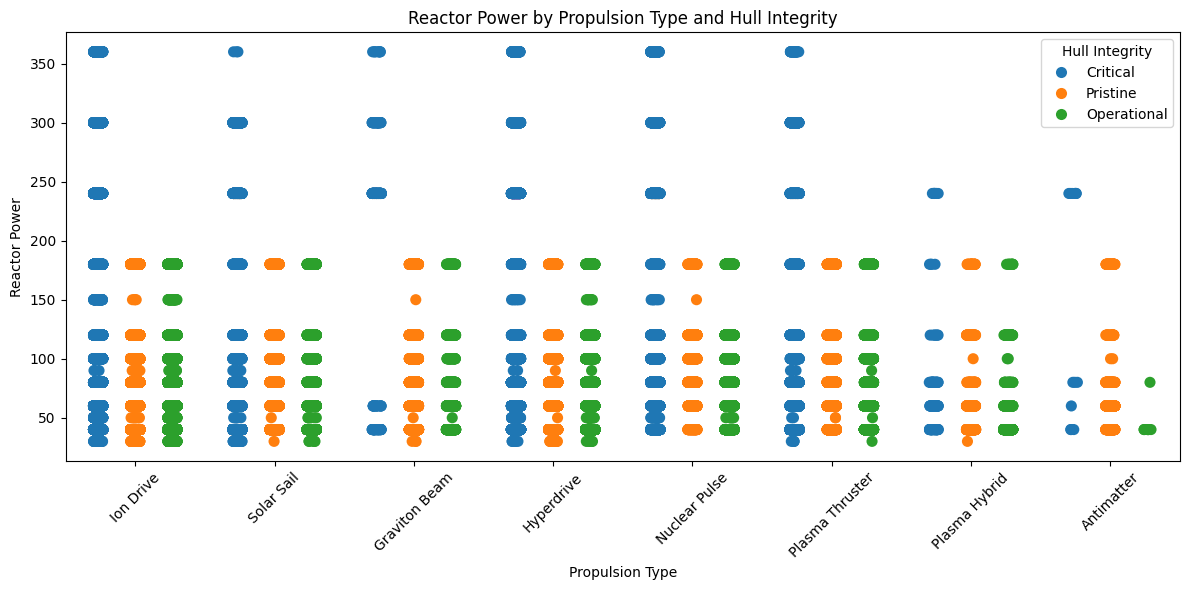

In [34]:
plt.figure(figsize=(12,6))
sns.stripplot(x='Propulsion_Type', y='Reactor_Power', hue='Hull_Integrity', 
              data=df, jitter=True, dodge=True, size=8)
plt.title('Reactor Power by Propulsion Type and Hull Integrity')
plt.xlabel('Propulsion Type')
plt.ylabel('Reactor Power')
plt.xticks(rotation=45)
plt.legend(title='Hull Integrity')
plt.tight_layout()
plt.show()

c:\Users\naimi\Documents\HBO-ICT\Year2\Block3\Rabbitions\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


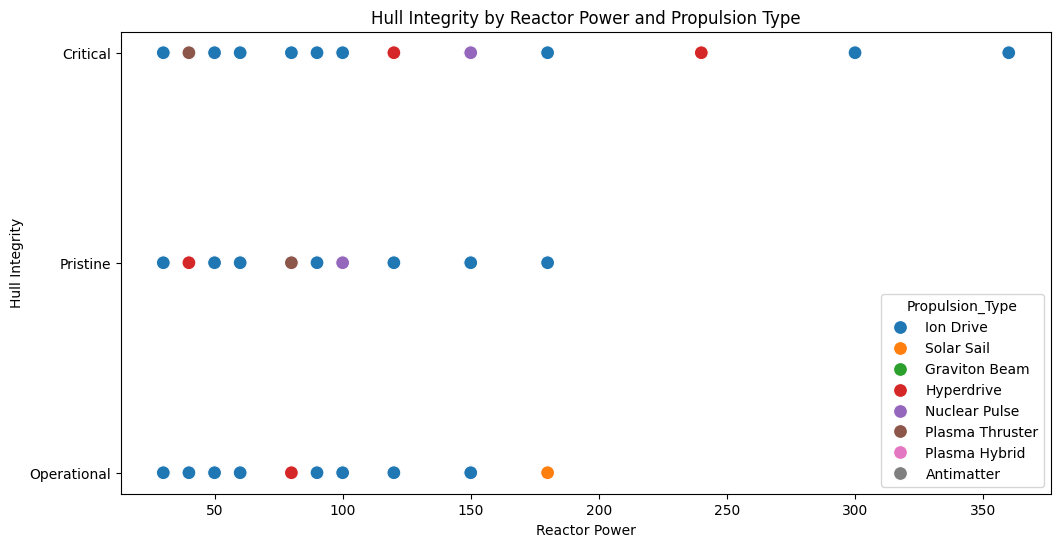

In [33]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='Reactor_Power', y='Hull_Integrity', hue='Propulsion_Type', data=df, s=100)
plt.title('Hull Integrity by Reactor Power and Propulsion Type')
plt.xlabel('Reactor Power')
plt.ylabel('Hull Integrity')
plt.show()

With this graph you can see how Reactor Power and Propulsion_type have effect on the Condition of the ship. (since it was asked to show aswell)
IMPORTANT NOTE : PLEASE MAKE LEARN AND THE NOTEBOOKS ON THE SAME INSTRUCTIONS, it is very confusing thank you.

**Data Quality Checks**


In [35]:
missing = df.isnull().mean() * 100
print("Percentage of missing values per column:\n", missing)

Percentage of missing values per column:
 Ship_ID               0.000000
Galactic_Credits      0.000000
Model_Cycle           2.008612
Ship_Manufacturer     0.000000
Sector                0.000000
Hull_Integrity        0.000000
Reactor_Power         7.992637
Propulsion_Type      15.370038
Ship_Class            0.000000
Class_Propulsion     15.370038
dtype: float64


In [36]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [37]:
print("Unique Propulsion Types:", df['Propulsion_Type'].unique())
print("Unique Ship Classes:", df['Ship_Class'].unique())
print("Unique Manufacturers:", df['Ship_Manufacturer'].unique())

Unique Propulsion Types: <StringArray>
[      'Ion Drive',      'Solar Sail',   'Graviton Beam',      'Hyperdrive',
               nan,   'Nuclear Pulse', 'Plasma Thruster',   'Plasma Hybrid',
      'Antimatter']
Length: 9, dtype: str
Unique Ship Classes: <StringArray>
[        'Shuttle',          'Hauler',        'Explorer',         'Fighter',
       'Freighter',        'Corvette',       'Speedster', 'Troop Transport']
Length: 8, dtype: str
Unique Manufacturers: <StringArray>
[            'Galactic Motors',          'Republic Aerospace',
           'Nebula Industries',       'Corellian Engineering',
         'General Mining Corp',               'Hondo Systems',
 'Bayerische Motoren Wormhole',     'Independent Shipwrights',
            'Kuat Drive Yards',                 'Droid Works',
              'Mercurian Benz',            'Galactic Motors ',
               'Jumpship Corp',      'Independent Shipwright',
                 'Independent',                  'Kuat Drive',
             '

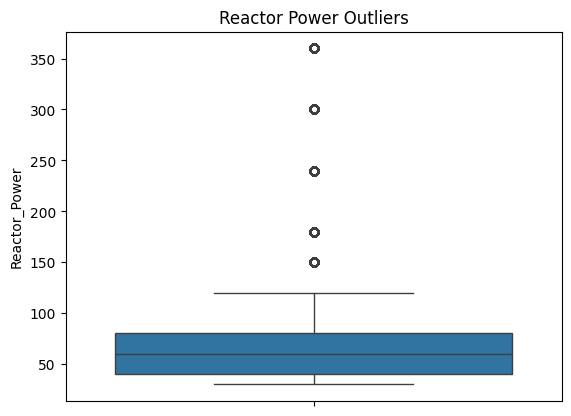

In [38]:
sns.boxplot(y='Reactor_Power', data=df)
plt.title('Reactor Power Outliers')
plt.show()

Propulsion_type / Class_Propulsion and Reactor Power have missing values.
no dupes
with Manufacotors the are some manufacotors with almost the same name
we have multiple outliers in Reactor Power


---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify how you resolve the missing values.*

In [ ]:
# CODE CELL: Data cleaning, preprocessing

**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [5]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Build a manual classifier. Use the insights from step 2 to write a Python function with if/elif/else statements that predicts the Hull_Condition for each ship. Apply this function to your dataset and save the predictions in a new column.*

In [ ]:
# CODE CELL: Model training and setup code

**Testing and performance**
*Evaluate your manual rules. Calculate the metrics and generate a **confusion matrix** (visualize this using seaborn/matplotlib).*

In [1]:
# CODE CELL: Model evaluation code

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*How well does your manual model identify 'Critical' or 'Pristine' ships? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What are the limitations of a manual, hard-rule-based system? Why might a machine Learning model be better in the next iteration?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset for the next iteration. 

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |